# Naive Bayes Classification  - TCGA Clinical Data  

In [184]:
install.packages('e1071')
#https://search.r-project.org/CRAN/refmans/e1071/html/naiveBayes.html


The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//RtmppWoLb1/downloaded_packages


In [126]:
install.packages("dplyr")
install.packages("tidyverse")


The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//RtmppWoLb1/downloaded_packages

The downloaded binary packages are in
	/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T//RtmppWoLb1/downloaded_packages


In [185]:
library(dplyr)
library(tidyverse)
library(e1071)
library(ggplot2)

In [231]:
#read in data 
data <- read.csv("coadread_tcga_pan_can_atlas_2018_clinical_data_cleaned.csv")

In [232]:
head(data)
colnames(data)

,Diagnosis.Age,Neoplasm.Disease.Stage.American.Joint.Committee.on.Cancer.Code,American.Joint.Committee.on.Cancer.Publication.Version.Type,Aneuploidy.Score,Cancer.Type,Cancer.Type.Detailed,Months.of.disease.specific.survival,Disease.specific.Survival.status,Ethnicity.Category,Fraction.Genome.Altered,⋯,Race.Category,Radiation.Therapy,Sex,Subtype,Tumor.Break.Load,TMB..nonsynonymous.,Tumor.Disease.Anatomic.Site,Patient.Weight,aneuploidy_group,OS_Status
,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>
1,61,STAGE I,7TH,19,Colorectal Cancer,Colon Adenocarcinoma,15.616267,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.1127,⋯,Black or African American,No,Female,COAD_CIN,19,4.033333,Colon,63.300,Mid,0
2,67,STAGE IIIB,7TH,13,Colorectal Cancer,Colon Adenocarcinoma,4.799947,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.3130,⋯,Black or African American,No,Male,COAD_CIN,30,2.900000,Colon,134.000,Mid,0
3,42,STAGE IIA,7TH,18,Colorectal Cancer,Mucinous Adenocarcinoma of the Colon and Rectum,12.657396,0:ALIVE OR DEAD TUMOR FREE,Not Hispanic Or Latino,0.2816,⋯,Black or African American,No,Female,COAD_CIN,14,4.000000,Colon,107.956,Mid,0
4,74,STAGE IV,6TH,18,Colorectal Cancer,Colon Adenocarcinoma,1.610941,1:DEAD WITH TUMOR,Hispanic Or Latino,0.4095,⋯,Black or African American,No,Male,COAD_CIN,82,5.833333,Colon,NA,Mid,1
5,40,STAGE IV,6TH,3,Colorectal Cancer,Colon Adenocarcinoma,9.534142,1:DEAD WITH TUMOR,Hispanic Or Latino,0.0500,⋯,Black or African American,No,Female,COAD_MSI,1,62.166667,Colon,99.100,Low,1
6,76,STAGE IIA,7TH,20,Colorectal Cancer,Colon Adenocarcinoma,39.451622,0:ALIVE OR DEAD TUMOR FREE,Hispanic Or Latino,0.4018,⋯,Black or African American,No,Male,COAD_CIN,27,3.800000,Colon,75.400,Mid,0


[1] "Diagnosis.Age"                                                            
 [2] "Neoplasm.Disease.Stage.American.Joint.Committee.on.Cancer.Code"           
 [3] "American.Joint.Committee.on.Cancer.Publication.Version.Type"              
 [4] "Aneuploidy.Score"                                                         
 [5] "Cancer.Type"                                                              
 [6] "Cancer.Type.Detailed"                                                     
 [7] "Months.of.disease.specific.survival"                                      
 [8] "Disease.specific.Survival.status"                                         
 [9] "Ethnicity.Category"                                                       
[10] "Fraction.Genome.Altered"                                                  
[11] "Genetic.Ancestry.Label"                                                   
[12] "Neoadjuvant.Therapy.Type.Administered.Prior.To.Resection.Text"            
[13] "MSI.MANTIS.Score"                                                         
[14] "MSIsensor.Score"                                                          
[15] "Mutation.Count"                                                           
[16] "New.Neoplasm.Event.Post.Initial.Therapy.Indicator"                        
[17] "Overall.Survival..Months."                                                
[18] "Overall.Survival.Status"                                                  
[19] "American.Joint.Committee.on.Cancer.Metastasis.Stage.Code"                 
[20] "Neoplasm.Disease.Lymph.Node.Stage.American.Joint.Committee.on.Cancer.Code"
[21] "American.Joint.Committee.on.Cancer.Tumor.Stage.Code"                      
[22] "Person.Neoplasm.Cancer.Status"                                            
[23] "Progress.Free.Survival..Months."                                          
[24] "Progression.Free.Status"                                                  
[25] "Prior.Diagnosis"                                                          
[26] "Race.Category"                                                            
[27] "Radiation.Therapy"                                                        
[28] "Sex"                                                                      
[29] "Subtype"                                                                  
[30] "Tumor.Break.Load"                                                         
[31] "TMB..nonsynonymous."                                                      
[32] "Tumor.Disease.Anatomic.Site"                                              
[33] "Patient.Weight"                                                           
[34] "aneuploidy_group"                                                         
[35] "OS_Status"

In [233]:
#rename stage col
#r syntax reminder- new_col = old_col
data <- data %>%
  rename(Stage = Neoplasm.Disease.Stage.American.Joint.Committee.on.Cancer.Code)


Naive Bayes assumes all features are independent, so we'll try to select features that won't be too correlated. If performance is poor, might need to look at a correlation matrix.  

In [234]:
#select the cols
subset <- data %>% 
  select(Stage, Diagnosis.Age, Aneuploidy.Score, Cancer.Type.Detailed, Fraction.Genome.Altered, Sex, Mutation.Count)


In [235]:
#print all unique values in "Stage"
print(unique(subset$Stage))

 [1] "STAGE I"    "STAGE IIIB" "STAGE IIA"  "STAGE IV"   "STAGE IIB" 
 [6] "STAGE IIIC" "STAGE II"   "STAGE IVA"  "STAGE IIC"  "STAGE III" 
[11] "STAGE IIIA" ""           "STAGE IVB"  "STAGE IA"  


In [236]:
#looks like there are some values that are just the empty string, not "NA"s, so need to drop those
subset <- subset %>% filter(Stage != "")

In [217]:
#write out the subset to a csv
write.csv(subset, "nb_data.csv", row.names = FALSE)

In [237]:
#split to train and test
set.seed(99)
train_index <- sample(1:nrow(subset), 0.7 * nrow(subset))
train_data <- subset[train_index, ]
test_data <- subset[-train_index, ]


In [240]:
#do we have each stage represented in both datasets?
print(sort(unique(train_data$Stage)))
print("")
print(sort(unique(test_data$Stage)))

 [1] "STAGE I"    "STAGE IA"   "STAGE II"   "STAGE IIA"  "STAGE IIB" 
 [6] "STAGE III"  "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"  
[11] "STAGE IVA"  "STAGE IVB" 
[1] ""
 [1] "STAGE I"    "STAGE II"   "STAGE IIA"  "STAGE IIB"  "STAGE IIC" 
 [6] "STAGE III"  "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"  
[11] "STAGE IVA" 


In [241]:
#retain only the stages present in both datasets
common_stages <- intersect(sort(unique(train_data$Stage)), sort(unique(test_data$Stage)))
train_data <- train_data[train_data$Stage %in% common_stages, ]
test_data <- test_data[test_data$Stage %in% common_stages, ]


In [260]:
print(sort(unique(train_data$Stage)))
print("")
print(sort(unique(test_data$Stage)))

 [1] "STAGE I"    "STAGE II"   "STAGE IIA"  "STAGE IIB"  "STAGE III" 
 [6] "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"   "STAGE IVA" 
[1] ""
 [1] "STAGE I"    "STAGE II"   "STAGE IIA"  "STAGE IIB"  "STAGE III" 
 [6] "STAGE IIIA" "STAGE IIIB" "STAGE IIIC" "STAGE IV"   "STAGE IVA" 


In [250]:
#remove these from the original subset prior to split
filtered_stages <- subset %>% filter(Stage %in% common_stages)

In [251]:
#write out
write.csv(train_data, "train_data_filtered.csv", row.names = FALSE)
write.csv(test_data, "test_data_filtered.csv", row.names = FALSE)
write.csv(filtered_stages, "filtered_stages.csv", row.names = FALSE)

In [245]:
nb_model <- naiveBayes(Stage ~ ., data = train_data)
print(nb_model)


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
   STAGE I   STAGE II  STAGE IIA  STAGE IIB  STAGE III STAGE IIIA STAGE IIIB 
0.17728532 0.05817175 0.29916898 0.01385042 0.03601108 0.03047091 0.12742382 
STAGE IIIC   STAGE IV  STAGE IVA 
0.09972299 0.10249307 0.05540166 

Conditional probabilities:
            Diagnosis.Age
Y                [,1]     [,2]
  STAGE I    66.76562 11.24580
  STAGE II   69.04762 14.04093
  STAGE IIA  68.75926 11.92176
  STAGE IIB  69.00000 14.57738
  STAGE III  63.92308 13.41306
  STAGE IIIA 62.27273 16.95931
  STAGE IIIB 66.47826 11.17684
  STAGE IIIC 64.00000 12.95266
  STAGE IV   67.08108 10.91477
  STAGE IVA  60.70000 13.54563

            Aneuploidy.Score
Y                [,1]     [,2]
  STAGE I    11.26562 7.314352
  STAGE II   10.47619 6.104253
  STAGE IIA  12.33333 7.378929
  STAGE IIB  11.00000 9.669540
  STAGE III  14.84615 7.186169
  STAGE IIIA 16.18182 5.653639


In [246]:
predictions <- predict(nb_model, test_data)
print(predictions)

  [1] STAGE IVA  STAGE IIIC STAGE IIIC STAGE IIIC STAGE IIIC STAGE IVA 
  [7] STAGE III  STAGE III  STAGE IIIC STAGE IIIC STAGE IIIC STAGE I   
 [13] STAGE III  STAGE IVA  STAGE IIIC STAGE IIA  STAGE IIIC STAGE IIIC
 [19] STAGE IIA  STAGE IVA  STAGE IIIB STAGE IIIB STAGE IIIB STAGE IIA 
 [25] STAGE IIIB STAGE III  STAGE IVA  STAGE IVA  STAGE IIIC STAGE III 
 [31] STAGE IVA  STAGE IIIB STAGE IIIC STAGE IVA  STAGE III  STAGE IIA 
 [37] STAGE IIIC STAGE IIA  STAGE IIA  STAGE IIIC STAGE IVA  STAGE IIIC
 [43] STAGE IIIC STAGE IIIC STAGE IIA  STAGE IIIC STAGE IVA  STAGE IV  
 [49] STAGE IIA  STAGE IIIB STAGE IIA  STAGE IIIC STAGE III  STAGE IIA 
 [55] STAGE IVA  STAGE IIIB STAGE IVA  STAGE IIIA STAGE IIIC STAGE IVA 
 [61] STAGE IIIB STAGE IIIB STAGE IVA  STAGE IIIB STAGE IVA  STAGE IIIB
 [67] STAGE I    STAGE IIIB STAGE IIIB STAGE IIIB STAGE IIIC STAGE IIIA
 [73] STAGE IIIC STAGE IIIA STAGE IIA  STAGE IIA  STAGE IIIC STAGE IIIC
 [79] STAGE IIIC STAGE IIIB STAGE IIIC STAGE IIA  STAGE I    STA

In [247]:
confusion_matrix <- table(Predicted = predictions, Actual = test_data$Stage)
print(confusion_matrix)

            Actual
Predicted    STAGE I STAGE II STAGE IIA STAGE IIB STAGE III STAGE IIIA
  STAGE I          1        0         0         0         0          0
  STAGE II         0        0         0         0         0          0
  STAGE IIA        5        2         5         1         2          0
  STAGE IIB        0        0         0         0         0          0
  STAGE III        6        2         1         0         0          0
  STAGE IIIA       2        0         4         1         0          0
  STAGE IIIB       7        1         6         1         1          0
  STAGE IIIC       3        2        19         0         1          1
  STAGE IV         0        0         0         0         0          0
  STAGE IVA        3        2         5         0         1          1
            Actual
Predicted    STAGE IIIB STAGE IIIC STAGE IV STAGE IVA
  STAGE I             2          1        0         0
  STAGE II            0          0        0         0
  STAGE IIA        

In [248]:
#calculate accuracy
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
print(accuracy)

[1] 0.09090909


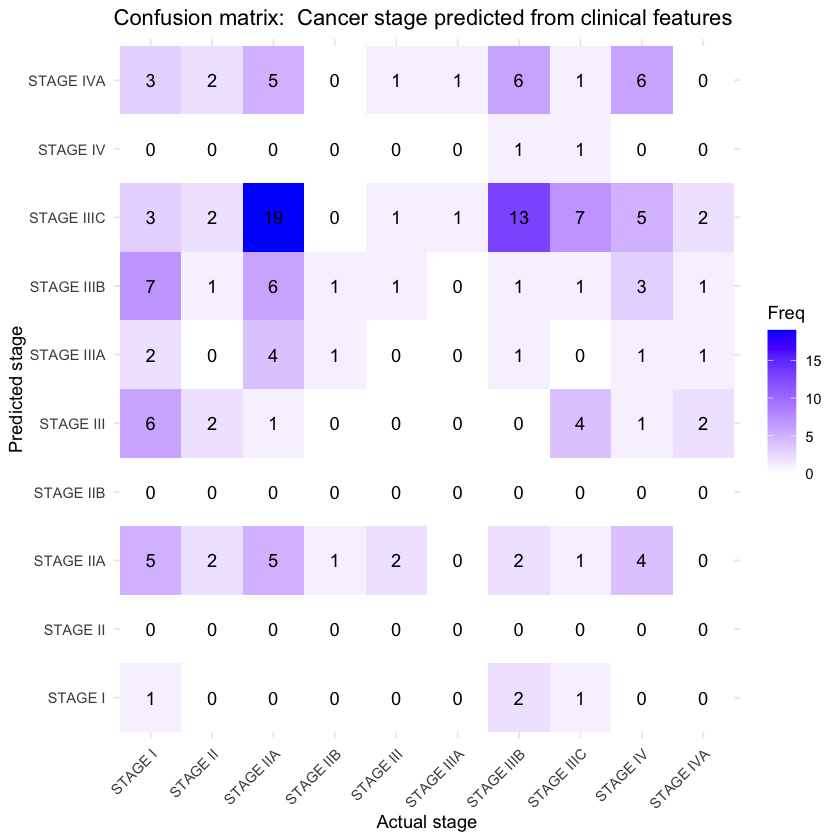

In [249]:
#plot the results of the model
ggplot(data= as.data.frame(confusion_matrix), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(title = "Confusion matrix:  Cancer stage predicted from clinical features", x= "Actual stage", y = "Predicted stage")


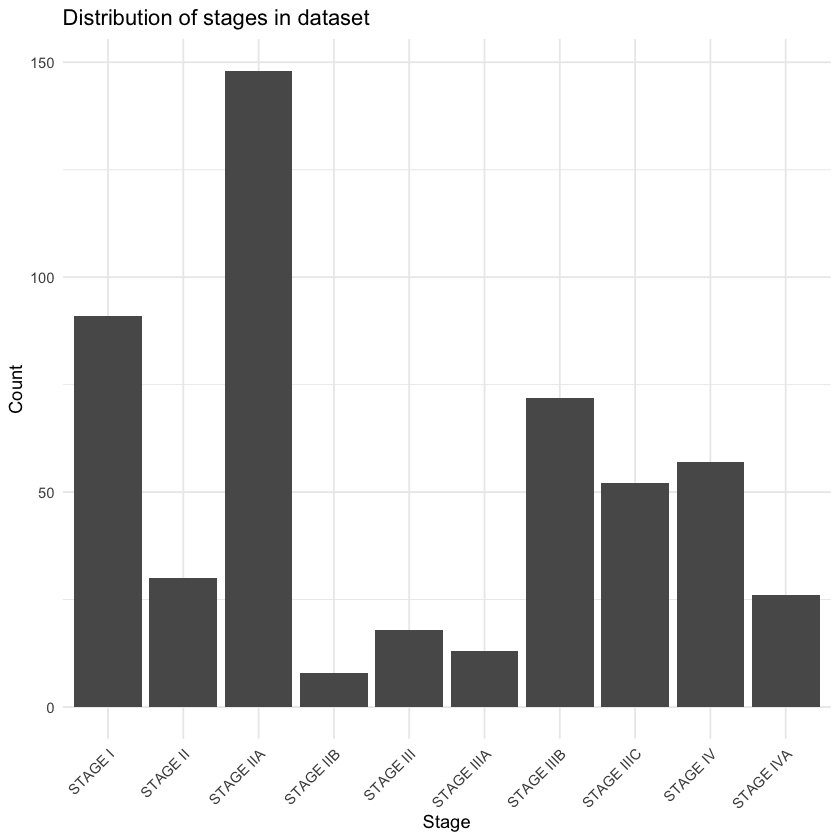

In [252]:
ggplot(filtered_stages, aes(x = Stage)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Distribution of stages in dataset", x = "Stage", y = "Count") +
  #adding this to rotate x-axis labels for better readability
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

So this is not a super accurate model...maybe reducing the number of stage categories to just the I/II/III/IV would be easier

In [253]:
#add a column that just keeps STAGE I, II, III, or IV, not the subtypes A and B
filtered_stages$Stage_Simple <- gsub("A|B|C|D", "", filtered_stages$Stage)
#drop the original Stage column
filtered_stages_simple <- filtered_stages %>% select(-Stage)



In [255]:
#re-split the data into train and test based on the simplified stage
set.seed(99)
train_index <- sample(1:nrow(filtered_stages_simple), 0.7 * nrow(filtered_stages_simple))
train_data_simple <- filtered_stages_simple[train_index, ]
test_data_simple <- filtered_stages_simple[-train_index, ]

In [256]:
head(train_data_simple)
head(test_data_simple)

,Diagnosis.Age,Aneuploidy.Score,Cancer.Type.Detailed,Fraction.Genome.Altered,Sex,Mutation.Count,Stage_Simple
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
432,72,11,Rectal Adenocarcinoma,0.2741,Female,138,STGE II
289,66,2,Colon Adenocarcinoma,0.0544,Female,99,STGE III
246,85,20,Rectal Adenocarcinoma,0.1588,Female,110,STGE I
373,75,25,Colon Adenocarcinoma,0.6453,Male,169,STGE II
483,55,29,Colon Adenocarcinoma,0.2799,Female,85,STGE IV
362,82,21,Colon Adenocarcinoma,0.2052,Male,97,STGE I


,Diagnosis.Age,Aneuploidy.Score,Cancer.Type.Detailed,Fraction.Genome.Altered,Sex,Mutation.Count,Stage_Simple
,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<chr>
2,67,13,Colon Adenocarcinoma,0.3130,Male,85,STGE III
4,74,18,Colon Adenocarcinoma,0.4095,Male,176,STGE IV
6,76,20,Colon Adenocarcinoma,0.4018,Male,113,STGE II
12,68,8,Colon Adenocarcinoma,NA,Female,116,STGE III
16,73,13,Colon Adenocarcinoma,0.3353,Female,130,STGE II
17,57,20,Colon Adenocarcinoma,0.4112,Female,33,STGE IV


In [258]:
#rerun the model
nb_model <- naiveBayes(Stage_Simple ~ ., data = train_data_simple)
predictions <- predict(nb_model, test_data_simple)
confusion_matrix <- table(Predicted = predictions, Actual = test_data_simple$Stage_Simple)
print(confusion_matrix)
accuracy <- sum(diag(confusion_matrix)) / sum(confusion_matrix)
print(accuracy)


          Actual
Predicted  STGE I STGE II STGE III STGE IV
  STGE I        1       1        1       0
  STGE II       4      11        1       1
  STGE III     22      44       40      22
  STGE IV       0       1        4       2
[1] 0.3483871


Better, but not great... let's visualize some of the results.

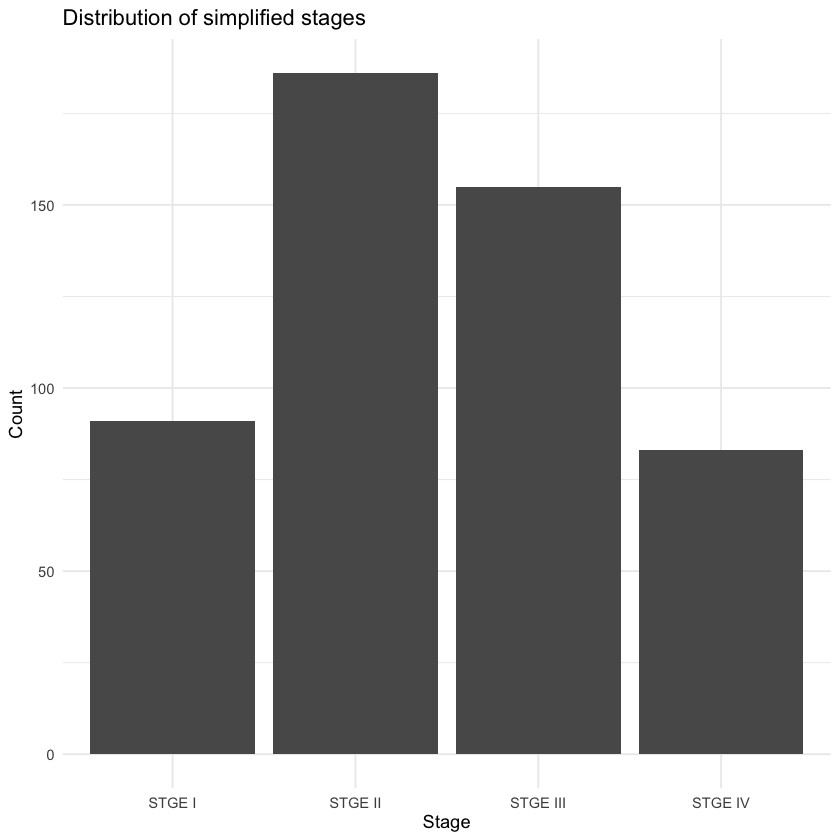

In [259]:
#dist plot
ggplot(filtered_stages_simple, aes(x = Stage_Simple)) +
  geom_bar() +
  theme_minimal() +
  labs(title = "Distribution of simplified stages", x = "Stage", y = "Count")

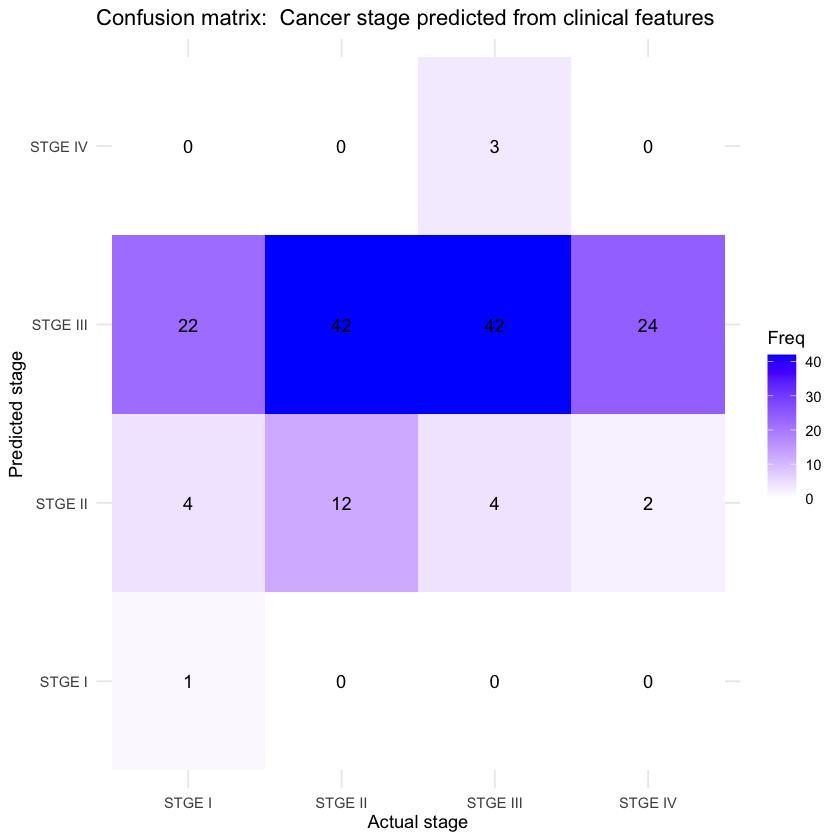

In [207]:
#conf matrix
ggplot(data= as.data.frame(confusion_matrix), aes(x= Actual, y=Predicted)) +
  geom_tile(aes(fill = Freq)) +
  geom_text(aes(label= Freq)) +
  scale_fill_gradient(low= "white", high = "blue") +
  theme_minimal() +
  labs(title = "Confusion matrix:  Cancer stage predicted from clinical features", x= "Actual stage", y = "Predicted stage")


In [ ]:
#since NB is fairly interpretable, we can look at
#how much each feature contributes to the model's predictions
feature_contributions <- map_dfr(names(nb_model$tables), function(feats) 
{
tbl <- as.matrix(nb_model$tables[[feats]])
# adding a small constant to avoid the log of zero, 
# as taking the log of zero is undefined
log_tbl <- log(tbl + 1e-9) 
tibble(feature = feats, discrimination = var(as.numeric(log_tbl)))
}) %>% arrange(desc(discrimination))



head(feature_contributions, 10)

feature,discrimination
<chr>,<dbl>
Diagnosis.Age,0.81779033
Cancer.Type.Detailed,0.78803267
Mutation.Count,0.32056098
Aneuploidy.Score,0.11362784
Fraction.Genome.Altered,0.09781184
Sex,0.03645057
